In [1]:
import pandas as pd
import numpy as np

In [2]:
path = 'country.csv' 

In [3]:
df = pd.read_csv(path, encoding='utf8')
df

,Code,Name,Continent,Region,SurfaceArea,IndepYear,Population,LifeExpectancy,GNP,GNPOld,LocalName,GovernmentForm,HeadOfState,Capital,Code2
0,ABW,Aruba,North America,Caribbean,193.0,NaN,103000,78.4,828.0,793.0,Aruba,Nonmetropolitan Territory of The Netherlands,Beatrix,129.0,AW
1,AFG,Afghanistan,Asia,Southern and Central Asia,652090.0,1919.0,22720000,45.9,5976.0,NaN,Afganistan/Afqanestan,Islamic Emirate,Mohammad Omar,1.0,AF
2,AGO,Angola,Africa,Central Africa,1246700.0,1975.0,12878000,38.3,6648.0,7984.0,Angola,Republic,José Eduardo dos Santos,56.0,AO
3,AIA,Anguilla,North America,Caribbean,96.0,NaN,8000,76.1,63.2,NaN,Anguilla,Dependent Territory of the UK,Elisabeth II,62.0,AI
4,ALB,Albania,Europe,Southern Europe,28748.0,1912.0,3401200,71.6,3205.0,2500.0,Shqipëria,Republic,Rexhep Mejdani,34.0,AL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,YEM,Yemen,Asia,Middle East,527968.0,1918.0,18112000,59.8,6041.0,5729.0,Al-Yaman,Republic,Ali Abdallah Salih,1780.0,YE
235,YUG,Yugoslavia,Europe,Southern Europe,102173.0,1918.0,10640000,72.4,17000.0,NaN,Jugoslavija,Federal Republic,Vojislav Koštunica,1792.0,YU
236,ZAF,South Africa,Africa,Southern Africa,1221037.0,1910.0,40377000,51.1,116729.0,129092.0,South Africa,Republic,Thabo Mbeki,716.0,ZA
237,ZMB,Zambia,Africa,Eastern Africa,752618.0,1964.0,9169000,37.2,3377.0,3922.0,Zambia,Republic,Frederick Chiluba,3162.0,ZM


https://dataedo.com/samples/html/World_MySQL/doc/World_(MySQL_database)_9/tables/country_3908.html

# 🟦 대륙별 인구수 & 국가수

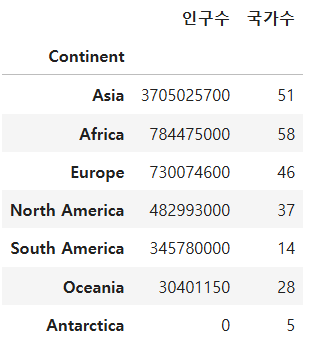

In [13]:
# TODO
df.groupby('Continent').agg(
    인구수=('Population', 'sum'),
    국가수=('Name', 'count'),
).sort_values('인구수', ascending=False)

,인구수,국가수
Continent,,
Asia,3705025700,51
Africa,784475000,58
Europe,730074600,46
North America,482993000,37
South America,345780000,14
Oceania,30401150,28
Antarctica,0,5


# 🟦 각 알파벳으로 시작하는 국가들은 각각 몇개나 될까?

In [32]:
# 각각의 알파벳으로 시작하는 국가들이 얼마나 될까?
"""
Name
A    15
B    20
C    22
D     4
E     8
F     8
G    15
H     6
I     8
J     3
K     5
L     9
M    22
N    15
O     1
P    12
Q     1
R     4
S    29
T    13
U     8
V     5
W     2
Y     2
Z     2
dtype: int64
"""
None

In [26]:
df.groupby(df.Name.apply(lambda x: x[0].upper())).size()

Name
A    15
B    20
C    22
D     4
E     8
F     8
G    15
H     6
I     8
J     3
K     5
L     9
M    22
N    15
O     1
P    12
Q     1
R     4
S    29
T    13
U     8
V     5
W     2
Y     2
Z     2
dtype: int64

# 🟦 대륙별 인구가 가장 많은 국가 1개씩
- 대륙별로 인구수가 가장 많은 나라 1개씩
- 대륙, 국가명, 인구수를 아래와 같이 결과 만들기

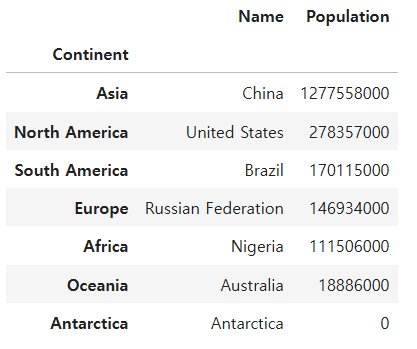

In [31]:
# TODO
df.groupby('Continent').apply(
    lambda cont_df: cont_df.sort_values('Population', ascending=False).head(1)
)[['Name', 'Population']]

,,Name,Population
Continent,,,
Africa,155,Nigeria,111506000
Antarctica,11,Antarctica,0
Asia,41,China,1277558000
Europe,181,Russian Federation,146934000
North America,223,United States,278357000
Oceania,14,Australia,18886000
South America,30,Brazil,170115000


# 🟦 대륙별, 인구합계,인구평균, 면적합계 
- 대륙별 
    - 인구는 "합계","평균"
    - 면적은 "합계 " 

[예시]
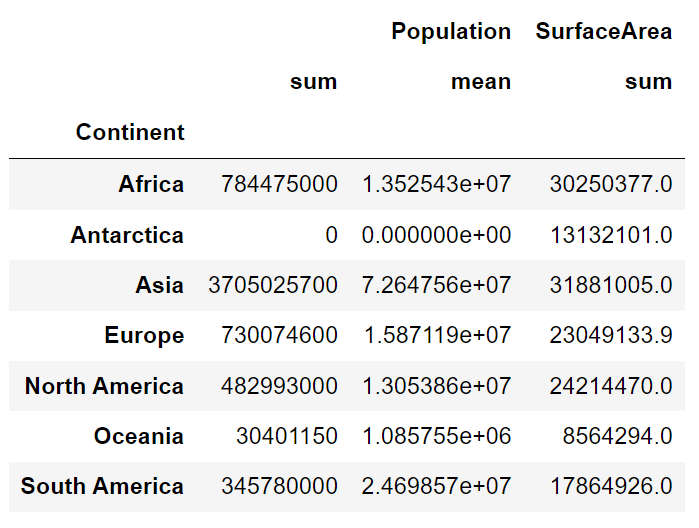

In [ ]:
# TODO

In [38]:
df.groupby('Continent').agg({
    'Population': ['sum', 'mean'],
    'SurfaceArea': 'sum',
})

Population               SurfaceArea
                      sum          mean         sum
Continent                                          
Africa          784475000  1.352543e+07  30250377.0
Antarctica              0  0.000000e+00  13132101.0
Asia           3705025700  7.264756e+07  31881005.0
Europe          730074600  1.587119e+07  23049133.9
North America   482993000  1.305386e+07  24214470.0
Oceania          30401150  1.085755e+06   8564294.0
South America   345780000  2.469857e+07  17864926.0

# 🟦 대륙별 평균 GNP 보다 높은 국가들

- 출력: 대륙, 국가, GNP, 대륙평균 GNP
- 정렬: 대륙명 오름차순, GNP 내림차순


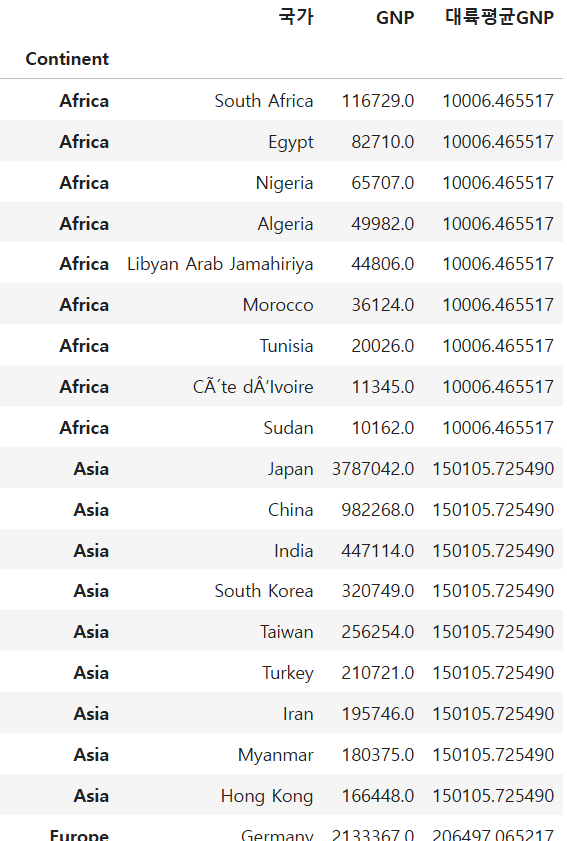

In [33]:
# TODO
df['GNP_mean'] = df.groupby('Continent')['GNP'].transform('mean')

df[['Continent', 'Name', 'GNP', 'GNP_mean']].head()

,Continent,Name,GNP,GNP_mean
0,North America,Aruba,828.0,261854.789189
1,Asia,Afghanistan,5976.0,150105.725490
2,Africa,Angola,6648.0,10006.465517
3,North America,Anguilla,63.2,261854.789189
4,Europe,Albania,3205.0,206497.065217


In [34]:
df.loc[df.GNP > df.GNP_mean, ['Continent', 'Name', 'GNP', 'GNP_mean']]\
  .sort_values(['Continent', 'GNP'], ascending=[True, False])

,Continent,Name,GNP,GNP_mean
236,Africa,South Africa,116729.0,10006.465517
63,Africa,Egypt,82710.0,10006.465517
155,Africa,Nigeria,65707.0,10006.465517
61,Africa,Algeria,49982.0,10006.465517
121,Africa,Libyan Arab Jamahiriya,44806.0,10006.465517
130,Africa,Morocco,36124.0,10006.465517
214,Africa,Tunisia,20026.0,10006.465517
42,Africa,Côte d’Ivoire,11345.0,10006.465517
184,Africa,Sudan,10162.0,10006.465517
109,Asia,Japan,3787042.0,150105.725490
